
ورودی مختصات:
1) UTM
2) Geographic (LAT/LON)



انتخاب (1 / 2):  2



انتخاب نوع مختصات برای نمایش در فایل KMZ / Excel / نمودار:

1) Universal Transverse Mercator - UTM
2) Geographic Coordinates (Decimal Degrees - DD)
3) Geographic Coordinates (DMS)



شماره مورد نظر را وارد کن (1 / 2 / 3):  2


✅ KMZ ساخته شد
✅ Excel ساخته شد
📏 مساحت: 2,816,833 m²
📐 محیط: 7,148.0 m


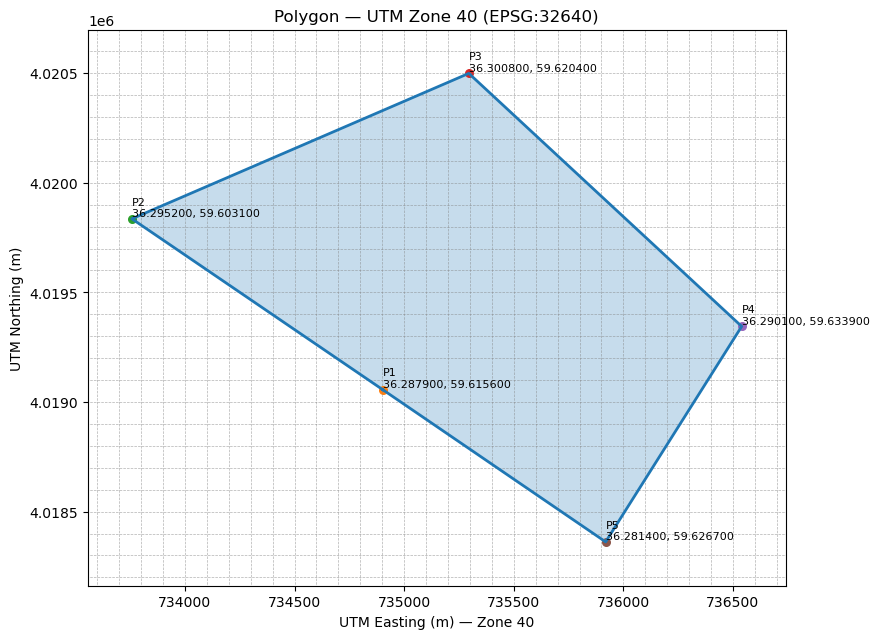


🔹 UTM:
(734903, 4019056)
(733758, 4019836)
(735295, 4020499)
(736540, 4019345)
(735919, 4018362)

🔹 LAT / LON:
(36.287900, 59.615600)
(36.295200, 59.603100)
(36.300800, 59.620400)
(36.290100, 59.633900)
(36.281400, 59.626700)


In [ ]:
# kmz_utm_export_professional_FINAL_SWAP23.py

from pykml.factory import KML_ElementMaker as KML
from lxml import etree
from pyproj import Transformer, Geod
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter
import zipfile, math
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# INPUT TYPE
# ======================================================
print("\nورودی مختصات:")
print("1) UTM")
print("2) Geographic (LAT/LON)\n")
input_type = input("انتخاب (1 / 2): ").strip()

# ======================================================
# INPUT COORDINATES
# ======================================================
zone = 40
fixed_epsg = 32600 + zone  # → 32638

if input_type == "1":  # UTM input
    utm_coords = [
        (600728, 3438140),
        (601621, 3438578),
        (602650, 3438208),
        (601347, 3437963),
        (602098, 3437580),
        (601196, 3437201)
    ]

    transformer = Transformer.from_crs(fixed_epsg, 4326, always_xy=True)
    longitudes, latitudes = zip(*[
        transformer.transform(x, y) for x, y in utm_coords
    ])

    epsg_int = fixed_epsg


else:  # LAT/LON input
    latlon_coords = [
    (36.2879, 59.6156),  # حرم امام رضا
    (36.2952, 59.6031),  # احمدآباد
    (36.3008, 59.6204),  # خیابان امام رضا
    (36.2901, 59.6339),  # طبرسی
    (36.2814, 59.6267)
    ]
    latitudes, longitudes = zip(*latlon_coords)
    zone = math.floor((sum(longitudes)/len(longitudes) + 180) / 6) + 1
    epsg_int = 32600 + zone
    transformer = Transformer.from_crs(4326, epsg_int, always_xy=True)
    utm_coords = [transformer.transform(lon, lat) for lat, lon in latlon_coords]

utm_zone_list = [zone] * len(latitudes)


# ======================================================
# DISPLAY TYPE SELECTION
# ======================================================
print("\nانتخاب نوع مختصات برای نمایش در فایل KMZ / Excel / نمودار:\n")
print("1) Universal Transverse Mercator - UTM")
print("2) Geographic Coordinates (Decimal Degrees - DD)")
print("3) Geographic Coordinates (DMS)\n")
choice = input("شماره مورد نظر را وارد کن (1 / 2 / 3): ").strip()


# ======================================================
# FUNCTIONS
# ======================================================
def to_dms(val, is_lat=True):
    d = int(abs(val))
    m = int((abs(val) - d) * 60)
    s = (abs(val) - d - m / 60) * 3600
    hemi = "N" if is_lat and val >= 0 else "S" if is_lat else "E" if val >= 0 else "W"
    return f"{d}°{m}'{s:.2f}\" {hemi}"

def label_text(lat, lon, utm):
    if choice == "1":      # UTM
        return f"X={int(round(utm[0]))}, Y={int(round(utm[1]))}"
    elif choice == "2":    # DD
        return f"{lat:.6f}, {lon:.6f}"
    else:                  # DMS
        return f"{to_dms(lat,True)}, {to_dms(lon,False)}"


# ======================================================
# POLYGON CLOSURE
# ======================================================
latitudes_closed = latitudes + (latitudes[0],)
longitudes_closed = longitudes + (longitudes[0],)
utm_coords_closed = utm_coords + [utm_coords[0]]

# ======================================================
# KMZ (Persian Turquoise – Thick & Transparent)
# ======================================================
coords_str = " ".join(f"{lon},{lat},0" for lat, lon in zip(latitudes_closed, longitudes_closed))

placemarks = [
    KML.Placemark(
        KML.name("Polygon Area"),
        KML.Style(
            KML.LineStyle(
                KML.color("ff3aa6a3"),  # فیروزه‌ای پررنگ
                KML.width("5")
            ),
            KML.PolyStyle(
                KML.color("803aa6a3")   # فیروزه‌ای نیمه شفاف
            )
        ),
        KML.Polygon(
            KML.outerBoundaryIs(
                KML.LinearRing(
                    KML.coordinates(coords_str)
                )
            )
        )
    )
]

for i, (lat, lon, utm) in enumerate(zip(latitudes, longitudes, utm_coords), 1):
    placemarks.append(
        KML.Placemark(
            KML.name(f"P{i}: {label_text(lat,lon,utm)}"),
            KML.Point(
                KML.coordinates(f"{lon},{lat},0")
            )
        )
    )

kml_doc = KML.kml(KML.Document(*placemarks))
with open("polygon_with_points.kml", "wb") as f:
    f.write(etree.tostring(kml_doc, pretty_print=True, encoding="UTF-8"))

with zipfile.ZipFile("polygon_with_points.kmz", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("polygon_with_points.kml", "doc.kml")

print("✅ KMZ ساخته شد")

# ======================================================
# EXCEL OUTPUT
# ======================================================
TURQUOISE = "009688"
LIGHT_TURQUOISE = "B2DFDB"

wb = Workbook()
ws = wb.active
ws.title = "Coordinates"

title = ws.cell(row=1, column=1, value="Project Coordinates Report")
title.font = Font(bold=True, size=16, color="FFFFFF")
title.fill = PatternFill(start_color=TURQUOISE, end_color=TURQUOISE, fill_type="solid")

max_col = 4 if choice == "1" else 3
ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=max_col)
title.alignment = Alignment(horizontal="center")

header_row = 3
if choice == "1":
    headers = ["Point", "Easting (m)", "Northing (m)", "Zone"]
elif choice == "2":
    headers = ["Point", "Latitude (DD)", "Longitude (DD)"]
else:
    headers = ["Point", "Latitude (DMS)", "Longitude (DMS)"]

thin = Border(*(Side(style="thin"),)*4)

for c, h in enumerate(headers, 1):
    cell = ws.cell(row=header_row, column=c, value=h)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill(start_color=TURQUOISE, end_color=TURQUOISE, fill_type="solid")
    cell.alignment = Alignment(horizontal="center")
    cell.border = thin

for i, (lat, lon, utm, z) in enumerate(zip(latitudes, longitudes, utm_coords, utm_zone_list), 1):
    r = header_row + i
    ws.cell(r,1,f"P{i}")
    if choice == "1":
        ws.cell(r,2,int(round(utm[0])))
        ws.cell(r,3,int(round(utm[1])))
        ws.cell(r,4,z)
    elif choice == "2":
        ws.cell(r,2,round(lat,6))
        ws.cell(r,3,round(lon,6))
    else:
        ws.cell(r,2,to_dms(lat,True))
        ws.cell(r,3,to_dms(lon,False))

    if i % 2 == 0:
        for c in range(1,max_col+1):
            ws.cell(r,c).fill = PatternFill(start_color=LIGHT_TURQUOISE,
                                            end_color=LIGHT_TURQUOISE,
                                            fill_type="solid")

for c in range(1,max_col+1):
    ws.column_dimensions[get_column_letter(c)].width = 22

wb.save("projected_coordinates.xlsx")
print("✅ Excel ساخته شد")

# ======================================================
# AREA & PERIMETER
# ======================================================
geod = Geod(ellps="WGS84")
area, perimeter = geod.polygon_area_perimeter(longitudes_closed, latitudes_closed)
print(f"📏 مساحت: {abs(area):,.0f} m²")
print(f"📐 محیط: {perimeter:,.1f} m")

# ======================================================
# PLOT (UTM GRID + POLYGON)
# ======================================================

# استخراج مختصات UTM
utm_x = [p[0] for p in utm_coords]
utm_y = [p[1] for p in utm_coords]

# محدوده نقشه با حاشیه
padding = 200
xmin, xmax = min(utm_x) - padding, max(utm_x) + padding
ymin, ymax = min(utm_y) - padding, max(utm_y) + padding

# تنظیم گرید
grid_size = 100
x_ticks = np.arange(
    math.floor(xmin / grid_size) * grid_size,
    math.ceil(xmax / grid_size) * grid_size + grid_size,
    grid_size
)
y_ticks = np.arange(
    math.floor(ymin / grid_size) * grid_size,
    math.ceil(ymax / grid_size) * grid_size + grid_size,
    grid_size
)

# ایجاد شکل
fig, ax = plt.subplots(figsize=(9, 9))

# رسم خطوط گرید
for xt in x_ticks:
    ax.plot([xt, xt], [y_ticks[0], y_ticks[-1]],
            linestyle='--', linewidth=0.5, color='gray', alpha=0.6)

for yt in y_ticks:
    ax.plot([x_ticks[0], x_ticks[-1]], [yt, yt],
            linestyle='--', linewidth=0.5, color='gray', alpha=0.6)

# پلیگون
poly_x = [p[0] for p in utm_coords_closed]
poly_y = [p[1] for p in utm_coords_closed]

ax.plot(poly_x, poly_y, linewidth=2)
ax.fill(poly_x, poly_y, alpha=0.25)

# نقاط و برچسب‌ها
for i, ((x, y), lat, lon) in enumerate(
        zip(utm_coords, latitudes, longitudes), start=1):

    ax.scatter(x, y, s=30)
    ax.text(
        x + grid_size * 0.02,
        y + grid_size * 0.02,
        f"P{i}\n{label_text(lat, lon, (x, y))}",
        fontsize=8,
        ha='left',
        va='bottom'
    )

# تنظیمات نهایی نمودار
ax.set_title(f"Polygon — UTM Zone {zone} (EPSG:{epsg_int})")
ax.set_xlabel(f"UTM Easting (m) — Zone {zone}")
ax.set_ylabel("UTM Northing (m)")
ax.set_aspect("equal")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

plt.show()



# ======================================================
# DISPLAY COORDINATES
# ======================================================

print("\n🔹 UTM:")
for x, y in utm_coords:
    print(f"({int(round(x))}, {int(round(y))})")

print("\n🔹 LAT / LON:")
for lat, lon in zip(latitudes, longitudes):
    print(f"({lat:.6f}, {lon:.6f})")



In [ ]:
from IPython.display import FileLink, display
# فایل‌ها را لینک دانلود بدهید
display(FileLink("polygon_with_points.kmz"))

C:\Users\sadra\polygon_with_points.kmz

In [ ]:
from IPython.display import FileLink, display
# فایل‌ها را لینک دانلود بدهید
display(FileLink("projected_coordinates.xlsx"))

C:\Users\sadra\projected_coordinates.xlsx

In [ ]:
elevation and topography

In [ ]:
############################################################
# elevation_from_polygon_kmz.py
# Input : polygon_with_points.kmz
# Output: Excel + KML + KMZ
# Grid spacing: USER DEFINED (meters)
############################################################

import zipfile
import numpy as np
import pandas as pd
from shapely.geometry import Polygon, Point
from lxml import etree
from tqdm import tqdm
import srtm

# ---------------------------------------------------------
# 1) USER SETTINGS
# ---------------------------------------------------------
KMZ_INPUT = "polygon_with_points.kmz"

POINT_SPACING_M = 100     # <<< فاصله تقریبی نقاط (متر)
NO_DATA_VALUE = -9999

OUTPUT_EXCEL = "elevation_points.xlsx"
OUTPUT_KML   = "elevation_points.kml"
OUTPUT_KMZ   = "elevation_points.kmz"

# تبدیل متر به درجه (تقریب روی عرض جغرافیایی)
METER_TO_DEG = 1 / 111_320
resolution = POINT_SPACING_M * METER_TO_DEG

# ---------------------------------------------------------
# 2) LOAD POLYGON FROM KMZ
# ---------------------------------------------------------
print("⏳ Loading polygon from KMZ...")

with zipfile.ZipFile(KMZ_INPUT, "r") as kmz:
    kml_name = [n for n in kmz.namelist() if n.endswith(".kml")][0]
    kml_data = kmz.read(kml_name)

root = etree.fromstring(kml_data)
ns = {"kml": "http://www.opengis.net/kml/2.2"}

coords_text = root.find(
    ".//kml:Polygon//kml:outerBoundaryIs//kml:coordinates",
    namespaces=ns
).text.strip()

coords = []
for c in coords_text.split():
    lon, lat, *_ = map(float, c.split(","))
    coords.append((lon, lat))

polygon = Polygon(coords)
minx, miny, maxx, maxy = polygon.bounds

print("✅ Polygon loaded")
print("📐 Grid spacing:", POINT_SPACING_M, "m")

# ---------------------------------------------------------
# 3) GENERATE GRID POINTS INSIDE POLYGON
# ---------------------------------------------------------
print("⏳ Generating grid points...")

xs = np.arange(minx, maxx, resolution)
ys = np.arange(miny, maxy, resolution)

grid_points = []
for x in xs:
    for y in ys:
        p = Point(x, y)
        if polygon.contains(p) or polygon.touches(p):
            grid_points.append((y, x))  # lat, lon

print(f"✅ Total points: {len(grid_points)}")

# ---------------------------------------------------------
# 4) GET ELEVATION FROM SRTM
# ---------------------------------------------------------
print("⏳ Loading SRTM data...")
elevation_data = srtm.get_data()

def safe_elevation(lat, lon):
    try:
        e = elevation_data.get_elevation(lat, lon)
        return e if e is not None else NO_DATA_VALUE
    except:
        return NO_DATA_VALUE

records = []
for idx, (lat, lon) in enumerate(tqdm(grid_points), start=1):
    records.append({
        "Point_ID": idx,
        "Latitude": lat,
        "Longitude": lon,
        "Elevation_m": safe_elevation(lat, lon),
        "Spacing_m": POINT_SPACING_M,
        "Source": "SRTM"
    })

df = pd.DataFrame(records)

# ---------------------------------------------------------
# 5) SAVE EXCEL
# ---------------------------------------------------------
df.to_excel(OUTPUT_EXCEL, index=False)
print("📊 Excel saved:", OUTPUT_EXCEL)

# ---------------------------------------------------------
# 6) CREATE KML
# ---------------------------------------------------------
print("⏳ Creating KML...")

kml_header = """<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
<Document>
  <name>Elevation Grid</name>
"""

kml_footer = """
</Document>
</kml>
"""

placemarks = []
for _, r in df.iterrows():
    placemarks.append(f"""
    <Placemark>
      <name>ID {r['Point_ID']} | {r['Elevation_m']} m</name>
      <description>
        Latitude: {r['Latitude']}
        Longitude: {r['Longitude']}
        Elevation: {r['Elevation_m']} m
        Spacing: {r['Spacing_m']} m
        Source: {r['Source']}
      </description>
      <Point>
        <coordinates>{r['Longitude']},{r['Latitude']},{r['Elevation_m']}</coordinates>
      </Point>
    </Placemark>
    """)

kml_content = kml_header + "".join(placemarks) + kml_footer

with open(OUTPUT_KML, "w", encoding="utf-8") as f:
    f.write(kml_content)

print("📍 KML created:", OUTPUT_KML)

# ---------------------------------------------------------
# 7) CREATE KMZ
# ---------------------------------------------------------
with zipfile.ZipFile(OUTPUT_KMZ, "w", zipfile.ZIP_DEFLATED) as kmz:
    kmz.write(OUTPUT_KML, arcname="doc.kml")

print("🎉 KMZ created:", OUTPUT_KMZ)


⏳ Loading polygon from KMZ...
✅ Polygon loaded
📐 Grid spacing: 100 m
⏳ Generating grid points...
✅ Total points: 349
⏳ Loading SRTM data...


100%|████████████████████████████████████████████████████████████████████████████████| 349/349 [00:06<00:00, 53.69it/s]

4 2884802
📊 Excel saved: elevation_points.xlsx
⏳ Creating KML...


📍 KML created: elevation_points.kml
🎉 KMZ created: elevation_points.kmz


In [ ]:
from IPython.display import FileLink, display
# فایل‌ها را لینک دانلود بدهید
display(FileLink("elevation_points.kmz"))

C:\Users\sadra\elevation_points.kmz

In [ ]:
from IPython.display import FileLink, display
display(FileLink("elevation_points.xlsx"))

C:\Users\sadra\elevation_points.xlsx